# 06 · The Solver Landscape — what to reach for, all open-source

The solver is not magic. First we build a tiny **simplex** from scratch and watch it
walk the corners of the feasible region — the same walk every LP solver does. Then we
tour the real, open-source backends and show they all agree on the same model:

- **SciPy** (`linprog` / `milp`) — dependency-light, HiGHS under the hood.
- **PuLP + CBC** — the everyday MILP workhorse, readable modeling.
- **HiGHS** via `highspy` — the high-performance LP/MILP engine, MIT-licensed.
- **OR-Tools** — for larger and structured problems.

Commercial solvers (Gurobi, CPLEX) exist and pull ahead only on very large industrial
models; **HiGHS closes most of that gap**, and nothing here needs a license.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image

from src.datasets.scenarios import knapsack_scenario, product_mix_scenario
from src.exporters import save_fig, save_json
from src.models import knapsack, product_mix
from src.simplex.from_scratch import simplex_max
from src.solvers.backends import available_backends, compare_backends, solve

print("backends installed:", available_backends())

backends installed: ('scipy', 'pulp', 'highs', 'ortools')


## A simplex from scratch, walking the corners

Our teaching simplex handles the standard form `max c·x s.t. A x <= b, x >= 0`. We
hand it the product-mix matrices and watch it pivot from the origin to the optimal
corner, improving profit at every step — then check it against a library solver.

In [2]:
scenario = product_mix_scenario()
c, a, b = product_mix.as_matrices(scenario)
result = simplex_max(c, a, b)

print("status    :", result.status)
print("objective :", result.objective)
print("x (d, w)  :", result.x)
print("iterations:", result.iterations)
print("corners walked:", result.vertices)

library = solve(product_mix.build(scenario), backend="scipy")
assert abs(result.objective - library.objective) < 1e-6
print("\nmatches SciPy:", round(library.objective, 6))

status    : optimal
objective : 36.0
x (d, w)  : [2.0, 6.0]
iterations: 2
corners walked: [[0.0, 0.0], [0.0, 6.0], [2.0, 6.0]]



matches SciPy: 36.0


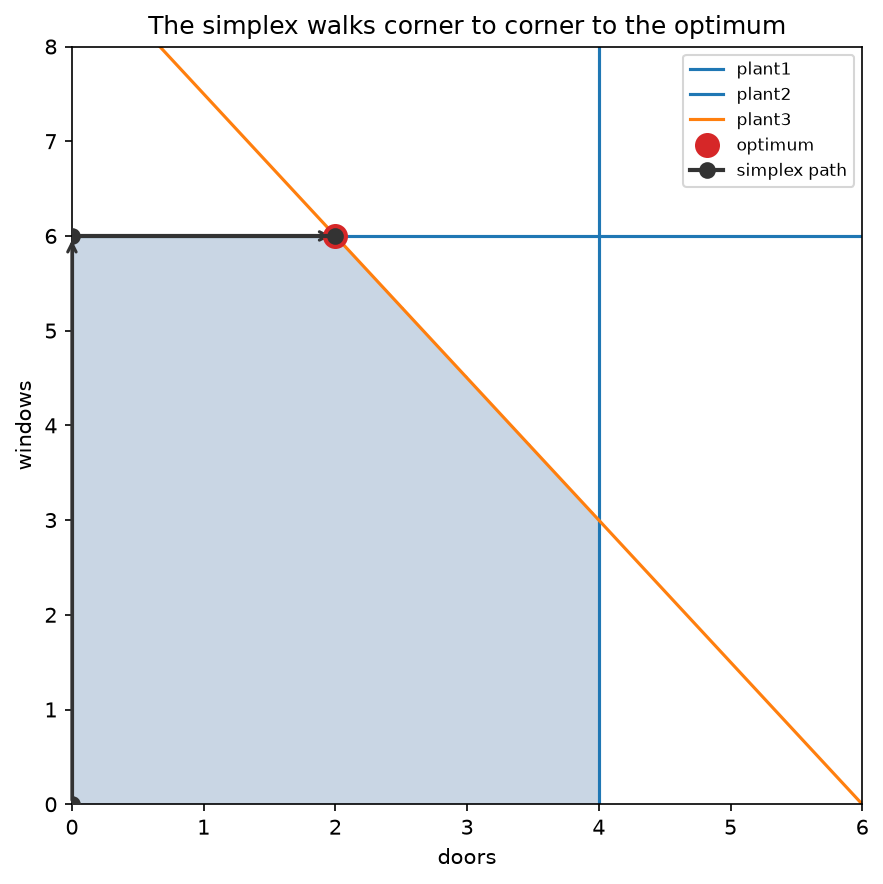

In [3]:
lp = product_mix.build(scenario)
from src.visualisation import plot_feasible_region

fig = plot_feasible_region(lp, library, x_max=6, y_max=8)
ax = fig.axes[0]
path_pts = np.array(result.vertices)
ax.plot(path_pts[:, 0], path_pts[:, 1], "-o", color="#333", linewidth=2,
        markersize=7, zorder=6, label="simplex path")
for i in range(len(path_pts) - 1):
    ax.annotate("", xy=path_pts[i + 1], xytext=path_pts[i],
                arrowprops=dict(arrowstyle="->", color="#333", lw=1.5))
ax.set_title("The simplex walks corner to corner to the optimum")
ax.legend(loc="upper right", fontsize=8)
path = save_fig(fig, "06_simplex_path")
plt.close(fig)
Image(str(path))

## Four open solvers, one optimum

`compare_backends` solves the *same* model through every backend. Because `highspy`
and `ortools` each statically bundle HiGHS and cannot share a process, each solve runs
in its own subprocess — so the comparison is honest and crash-free. They agree on the
optimum to numerical tolerance; they differ only in speed.

In [4]:
lp_results = compare_backends(lp)
print(f"{'backend':<10}{'objective':>12}{'time (ms)':>12}")
for name, s in lp_results.items():
    print(f"{name:<10}{s.objective:>12.4f}{s.solve_time * 1e3:>12.3f}")

objs = [s.objective for s in lp_results.values()]
assert max(objs) - min(objs) < 1e-5
print("\nall backends agree on the optimum:", round(objs[0], 4))

backend      objective   time (ms)
scipy          36.0000       3.656
pulp           36.0000       3.470
highs          36.0000       0.361
ortools        36.0000       0.301

all backends agree on the optimum: 36.0


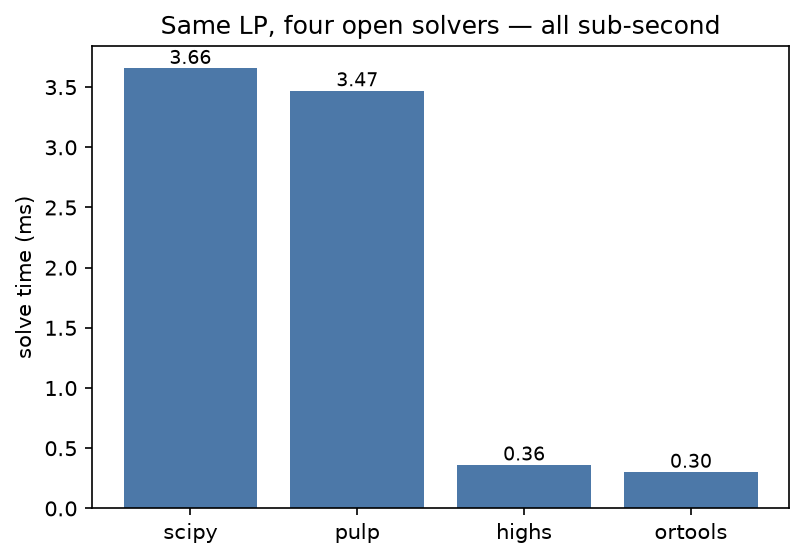

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
names = list(lp_results)
times = [lp_results[n].solve_time * 1e3 for n in names]
ax.bar(names, times, color="#4c78a8")
ax.set_ylabel("solve time (ms)")
ax.set_title("Same LP, four open solvers — all sub-second")
for i, t in enumerate(times):
    ax.text(i, t, f"{t:.2f}", ha="center", va="bottom", fontsize=9)
path = save_fig(fig, "06_solve_times")
plt.close(fig)
Image(str(path))

## They agree on MILPs too

The same holds for the 0/1 knapsack — an integer program — where PuLP and OR-Tools use
CBC, SciPy and HiGHS use branch-and-bound over HiGHS.

In [6]:
ks = knapsack_scenario()
milp_results = compare_backends(knapsack.build(ks))
for name, s in milp_results.items():
    print(f"{name:<10} value = {s.objective:.2f}")
milp_objs = [s.objective for s in milp_results.values()]
assert max(milp_objs) - min(milp_objs) < 1e-5
print("all agree on the integer optimum:", round(milp_objs[0], 2))

scipy      value = 220.00
pulp       value = 220.00
highs      value = 220.00
ortools    value = 220.00
all agree on the integer optimum: 220.0


In [7]:
save_json(
    {
        "from_scratch_simplex": {
            "objective": result.objective,
            "x": result.x,
            "iterations": result.iterations,
            "corners_walked": result.vertices,
            "matches_library": abs(result.objective - library.objective) < 1e-6,
        },
        "lp_comparison": {
            name: {"objective": s.objective, "solve_time_ms": s.solve_time * 1e3}
            for name, s in lp_results.items()
        },
        "milp_comparison": {
            name: {"objective": s.objective, "solve_time_ms": s.solve_time * 1e3}
            for name, s in milp_results.items()
        },
        "all_backends_agree": True,
    },
    "06_solver_landscape",
)
print("saved 06_solver_landscape.json")

saved 06_solver_landscape.json


## What to run

- Small LP, no extra dependency → **SciPy**.
- Everyday MILP, readable model → **PuLP + CBC**.
- Need speed, still open → **HiGHS** (`highspy`).
- Large or structured → **OR-Tools**.

Every project in this track runs entirely on these free, license-free tools. You now
have the whole toolkit: recognise the shape, name the three ingredients, call a
solver — and read the shadow prices it hands back for free.